# Shoreline Extraction using K-means

## Load data

In [58]:
from pathlib import Path
import numpy as np
import rasterio

import matplotlib.pyplot as plt

tif_path = Path(r"data\NSO_cropped_data\20200919.tif")

# open raster and read data
src = rasterio.open(tif_path)
img = src.read()  # shape: (bands, rows, cols)
meta = src.meta.copy()
crs = src.crs
transform = src.transform
bounds = src.bounds

Loaded data\NSO_cropped_data\20200919.tif -> bands: 3, shape: (648, 644), CRS: EPSG:28992


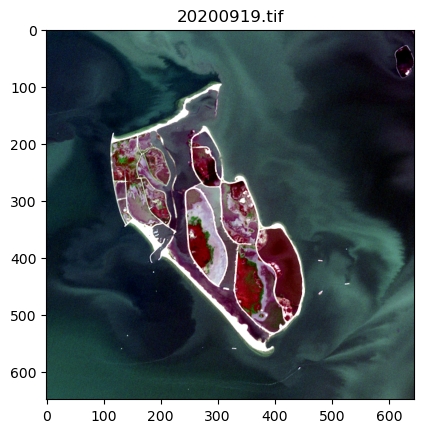

In [59]:
print(f"Loaded {tif_path} -> bands: {img.shape[0]}, shape: {img.shape[1:]}, CRS: {crs}")

# convenience: if single-band, make it 2D
if img.shape[0] == 1:
    img = img[0]

# quick preview: if multiband and has >=3 bands, show RGB, else show grayscale
if img.ndim == 3:
    if img.shape[0] >= 3:
        rgb = img[:3].astype('float32')
        # simple contrast stretch per band using 2-98 percentiles
        for i in range(3):
            band = rgb[i]
            mask = np.isfinite(band)
            if mask.any():
                p2, p98 = np.percentile(band[mask], (2, 98))
            else:
                p2, p98 = band.min(), band.max()
            rgb[i] = (band - p2) / (p98 - p2 + 1e-9)
        rgb = np.clip(np.transpose(rgb, (1, 2, 0)), 0, 1)
        plt.imshow(rgb)
    else:
        plt.imshow(img, cmap='gray')
else:
    plt.imshow(img, cmap='gray')

plt.title(tif_path.name)
plt.axis('on')
plt.show()

In [64]:
# print min max coordinates
print(f"Bounds: {bounds}")
print(f"Min X: {bounds.left}, Max X: {bounds.right}")
print(f"Min Y: {bounds.bottom}, Max Y: {bounds.top}")
# print resolution
print(f"Resolution: {transform.a} x {transform.e} (X x Y)") # transform.a is pixel width (positive-up), transform.e is pixel height (negative-down)

Bounds: BoundingBox(left=151718.61173381345, bottom=507732.1685169672, right=158158.61173381345, top=514212.1685169672)
Min X: 151718.61173381345, Max X: 158158.61173381345
Min Y: 507732.1685169672, Max Y: 514212.1685169672
Resolution: 10.0 x -10.0 (X x Y)


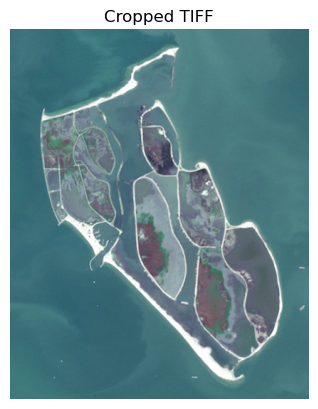

In [65]:
# Crop using pixel coordinates

import rasterio
from rasterio.windows import Window

# Open the TIFF
with rasterio.open(tif_path) as src:
    # Define pixel window: Window(col_off, row_off, width, height)
    window = Window(70, 70, 420, 520)  # example: crop 200x200 pixels starting at (100, 100)
    img_cropped = src.read(window=window)
    # Optionally, get the transform for the cropped window
    transform_cropped = src.window_transform(window)

# Show cropped image
plt.imshow(np.transpose(img_cropped[:3], (1, 2, 0)))
plt.title("Cropped TIFF")
plt.axis('off')
plt.show()

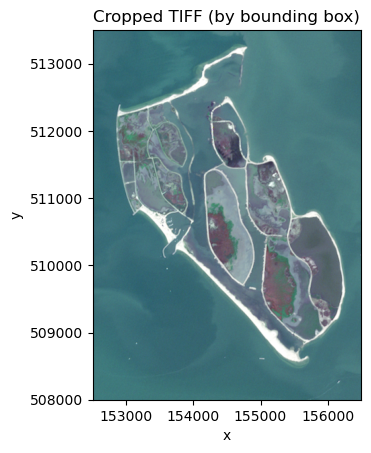

In [66]:
# Crop using bounding box in map coordinates

import rasterio
from rasterio.windows import from_bounds

# Define your bounding box (in map units, e.g., meters)
minx, miny, maxx, maxy = 152500, 508000, 156500, 513500  # example values

with rasterio.open(tif_path) as src:
    # Create a window from map bounds
    window = from_bounds(minx, miny, maxx, maxy, src.transform)
    img_cropped = src.read(window=window)
    transform_cropped = src.window_transform(window)

# Show cropped image (for RGB)
extent = (minx, maxx, miny, maxy) # extent in map coordinates
plt.imshow(np.transpose(img_cropped[:3], (1, 2, 0)), extent=extent)
plt.title("Cropped TIFF (by bounding box)")
plt.axis('on')
# add axis in bounding box coordinates
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [67]:
# print size of cropped image in bounding box unit
width = maxx - minx
height = maxy - miny
print(f"Cropped image size in map units: {width} x {height} (X x Y) meters")

Cropped image size in map units: 4000 x 5500 (X x Y) meters


## Implement K-means

### K-means of whole islands

Cluster means (k=2): [0.15952125, 0.6830571]
Water cluster (k=2): 0


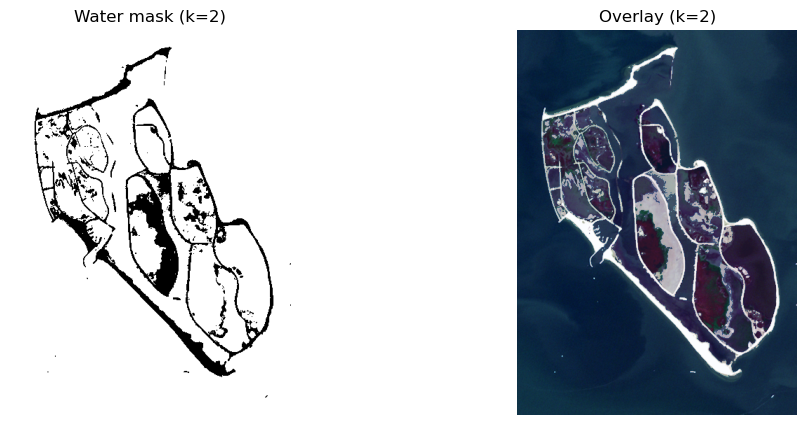

In [70]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Use cropped image as input band for K-means
# Convert cropped RGB (if present) to a single intensity band similar to the preview stretch
if 'img_cropped' in globals():
    if img_cropped.ndim == 3 and img_cropped.shape[0] >= 3:
        rgb_c = img_cropped[:3].astype('float32')
        # per-band contrast stretch (2-98 percentile)
        for i in range(3):
            b = rgb_c[i]
            m = np.isfinite(b)
            if m.any():
                p2, p98 = np.percentile(b[m], (2, 98))
            else:
                p2, p98 = b.min(), b.max()
            rgb_c[i] = (b - p2) / (p98 - p2 + 1e-9)
        rgb = np.clip(np.transpose(rgb_c, (1, 2, 0)), 0, 1)
        # convert to luminance/intensity
        band = (0.2989 * rgb[:, :, 0] + 0.5870 * rgb[:, :, 1] + 0.1140 * rgb[:, :, 2]).astype('float32')
    else:
        # single-band cropped image
        band = img_cropped[0].astype('float32') if img_cropped.ndim == 3 else img_cropped.astype('float32')
        # normalize to 0-1
        band = (band - np.nanmin(band)) / (np.nanmax(band) - np.nanmin(band) + 1e-9)
else:
    raise RuntimeError("img_cropped not found in the notebook namespace")

# mask valid pixels and prepare pixel array for clustering
mask = np.isfinite(band)
pixels = band[mask].reshape(-1, 1)

# K-means (k=2) classification to separate water vs land
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans.fit(pixels)

# rebuild full label image
labels = np.full(band.shape, -1, dtype=int)
labels[mask] = kmeans.labels_

# decide which cluster is water (lowest mean)
cluster_means = [pixels[kmeans.labels_ == i].mean() for i in range(2)]
water_cluster = int(np.argmin(cluster_means))
water_mask = (labels == water_cluster)

print("Cluster means (k=2):", cluster_means)
print("Water cluster (k=2):", water_cluster)

# visualize: mask alone and overlay on RGB if available
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(water_mask, cmap='gray')
plt.title('Water mask (k=2)')
plt.axis('off')

plt.subplot(1, 2, 2)
# if rgb exists and is 3-channel, show overlay; otherwise show band
if 'rgb' in globals() and rgb.ndim == 3 and rgb.shape[2] == 3:
    plt.imshow(rgb)
    plt.imshow(water_mask, cmap='Blues', alpha=0.4)
else:
    plt.imshow(band, cmap='gray')
    plt.imshow(water_mask, cmap='Blues', alpha=0.4)
plt.title('Overlay (k=2)')
plt.axis('off')

plt.show()

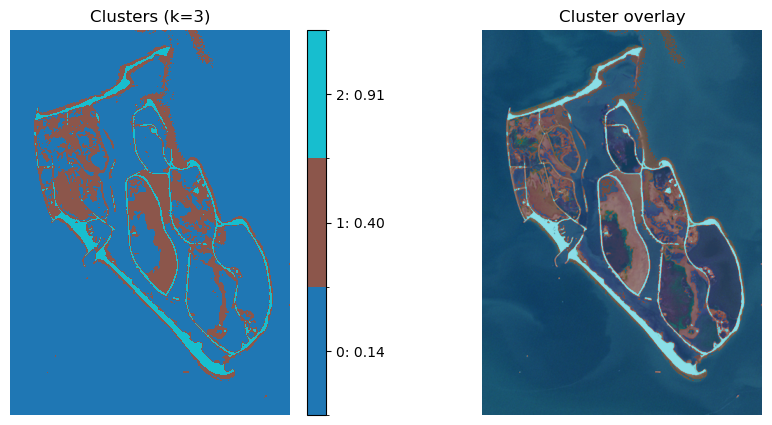

In [88]:
from matplotlib.colors import ListedColormap, BoundaryNorm

def kmeans_shoreline(img, k=2, contrast_percentiles=(2, 98),
                     random_state=0, n_init=20, transform=None, extent=None,
                     show_plot=True):
    """
    Run KMeans on an image to extract water (lowest-intensity cluster).
    Parameters:
      img: numpy array, accepted shapes:
           - (bands, rows, cols)  (bands-first, as in rasterio read)
           - (rows, cols, channels) (channels-last, e.g., HxWx3)
           - (rows, cols) single band
      k: number of clusters
      contrast_percentiles: tuple for per-band stretch (low, high)
      random_state, n_init: passed to sklearn.KMeans
      transform, extent: optional plotting params (extent is matplotlib extent)
      show_plot: if True, show mask and overlay
    Returns:
      dict with keys: labels (int label per pixel, -1 for nodata), water_mask (bool),
                      kmeans (fitted model), band (float 0-1 intensity), rgb (if available or None),
                      cluster_means (list)
    """
    # prepare image -> produce 'band' (2D float 0-1) and optional 'rgb' (HxWx3 float 0-1)
    rgb_out = None

    arr = img
    # bands-first (bands, rows, cols)
    if arr.ndim == 3 and arr.shape[0] in (1, 3, 4):
        # take first 3 bands for RGB if available
        if arr.shape[0] >= 3:
            rgb_c = arr[:3].astype('float32')
            # per-band contrast stretch
            lo, hi = contrast_percentiles
            for i in range(3):
                b = rgb_c[i]
                maskf = np.isfinite(b)
                if maskf.any():
                    p_lo, p_hi = np.percentile(b[maskf], (lo, hi))
                else:
                    p_lo, p_hi = b.min(), b.max()
                rgb_c[i] = (b - p_lo) / (p_hi - p_lo + 1e-9)
            rgb_out = np.clip(np.transpose(rgb_c, (1, 2, 0)), 0, 1)
            # luminance to single band
            band = (0.2989 * rgb_out[:, :, 0] + 0.5870 * rgb_out[:, :, 1] + 0.1140 * rgb_out[:, :, 2]).astype('float32')
        else:
            # single-band in bands-first
            band = arr[0].astype('float32')
            band = (band - np.nanmin(band)) / (np.nanmax(band) - np.nanmin(band) + 1e-9)
    # channels-last (rows, cols, channels)
    elif arr.ndim == 3 and arr.shape[2] in (3, 4):
        rgb_c = arr.astype('float32')
        # if likely 0-255, scale
        if rgb_c.max() > 1.0:
            rgb_c = rgb_c / 255.0
        # per-band stretch
        lo, hi = contrast_percentiles
        for i in range(3):
            b = rgb_c[:, :, i]
            maskf = np.isfinite(b)
            if maskf.any():
                p_lo, p_hi = np.percentile(b[maskf], (lo, hi))
            else:
                p_lo, p_hi = b.min(), b.max()
            rgb_c[:, :, i] = (b - p_lo) / (p_hi - p_lo + 1e-9)
        rgb_out = np.clip(rgb_c[:, :, :3], 0, 1)
        band = (0.2989 * rgb_out[:, :, 0] + 0.5870 * rgb_out[:, :, 1] + 0.1140 * rgb_out[:, :, 2]).astype('float32')
    elif arr.ndim == 2:
        band = arr.astype('float32')
        band = (band - np.nanmin(band)) / (np.nanmax(band) - np.nanmin(band) + 1e-9)
    else:
        raise ValueError("Unsupported image shape: " + str(arr.shape))

    # mask and pixels
    mask = np.isfinite(band)
    pixels = band[mask].reshape(-1, 1)
    if pixels.size == 0:
        raise RuntimeError("No valid pixels found for clustering")

    # run KMeans
    kmeans_model = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    kmeans_model.fit(pixels)

    # rebuild labels
    labels_full = np.full(band.shape, -1, dtype=int)
    labels_full[mask] = kmeans_model.labels_

    # cluster means
    cluster_means = []
    for i in range(k):
        sel = (kmeans_model.labels_ == i)
        if sel.any():
            cluster_means.append(float(pixels[sel].mean()))
        else:
            cluster_means.append(float('nan'))

    # choose water as the cluster with lowest mean intensity
    water_cluster = int(np.nanargmin(cluster_means))
    water_mask = (labels_full == water_cluster)

    # plotting: show each cluster in a different color
    if show_plot:

        plt.figure(figsize=(12, 5))

        # prepare discrete colormap
        base_cmap = plt.get_cmap('tab10' if k <= 10 else 'tab20')
        colors = base_cmap(np.linspace(0, 1, k))
        cmap_clusters = ListedColormap(colors)
        norm = BoundaryNorm(np.arange(-0.5, k + 0.5, 1), cmap_clusters.N)

        # turn -1 (nodata) into NaN so it plots transparent
        labels_vis = labels_full.astype(float)
        labels_vis[labels_vis == -1] = np.nan

        # left: cluster map
        plt.subplot(1, 2, 1)
        if extent is not None:
            im1 = plt.imshow(labels_vis, cmap=cmap_clusters, norm=norm, extent=extent, origin='upper')
        else:
            im1 = plt.imshow(labels_vis, cmap=cmap_clusters, norm=norm)
        plt.title(f'Clusters (k={k})')
        plt.axis('off')
        # colorbar with cluster means if available
        ticks = np.arange(k)
        try:
            tick_labels = [f"{i}: {cluster_means[i]:.2f}" for i in range(k)]
        except Exception:
            tick_labels = [str(i) for i in range(k)]
        cbar = plt.colorbar(im1, ticks=ticks, fraction=0.046, pad=0.04)
        cbar.ax.set_yticklabels(tick_labels)

        # right: overlay on RGB (or intensity) with transparency
        plt.subplot(1, 2, 2)
        if rgb_out is not None:
            if extent is not None:
                plt.imshow(rgb_out, extent=extent, origin='upper')
                plt.imshow(labels_vis, cmap=cmap_clusters, norm=norm, alpha=0.5, extent=extent, origin='upper')
            else:
                plt.imshow(rgb_out)
                plt.imshow(labels_vis, cmap=cmap_clusters, norm=norm, alpha=0.5)
        else:
            if extent is not None:
                plt.imshow(band, cmap='gray', extent=extent, origin='upper')
                plt.imshow(labels_vis, cmap=cmap_clusters, norm=norm, alpha=0.5, extent=extent, origin='upper')
            else:
                plt.imshow(band, cmap='gray')
                plt.imshow(labels_vis, cmap=cmap_clusters, norm=norm, alpha=0.5)
        plt.title('Cluster overlay')
        plt.axis('off')
        plt.show()

    return {
        'labels': labels_full,
        'water_mask': water_mask,
        'kmeans': kmeans_model,
        'band': band,
        'rgb': rgb_out,
        'cluster_means': cluster_means,
        'water_cluster': water_cluster
    }

# Example usage
result = kmeans_shoreline(img_cropped, k=3, transform=transform_cropped, extent=extent)


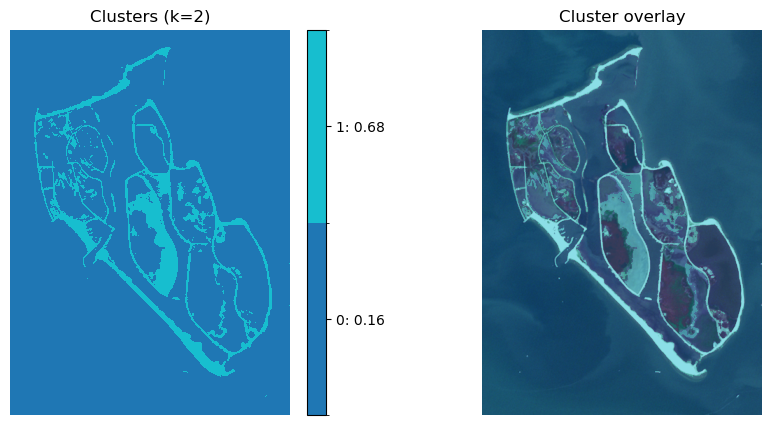

In [89]:
result = kmeans_shoreline(img_cropped, k=2, transform=transform_cropped, extent=extent)

In [91]:
result['labels'].shape

(550, 400)

### K-means with small pieces

In [101]:
from rasterio.windows import Window, transform as window_transform
import math

# parameters
patch_size = 200
drop_partial = False  # if True, skip patches smaller than patch_size on edges

# determine cropped image shape (handle bands-first or 2D)
arr = img_cropped
if arr.ndim == 3 and arr.shape[0] in (1, 3, 4):
    _, H, W = arr.shape
else:
    H, W = arr.shape

patches = []
n_row_patches = math.ceil(H / patch_size)
n_col_patches = math.ceil(W / patch_size)

for r in range(0, H, patch_size):
    for c in range(0, W, patch_size):
        h = min(patch_size, H - r)
        w = min(patch_size, W - c)
        if drop_partial and (h < patch_size or w < patch_size):
            continue

        win = Window(col_off=c, row_off=r, width=w, height=h)
        trans_patch = window_transform(win, transform_cropped)

        # compute bbox in map coords using patch transform
        # top-left (0,0), bottom-right (w, h)
        x0, y0 = trans_patch * (0, 0)
        x1, y1 = trans_patch * (w, h)
        minx, maxx = min(x0, x1), max(x0, x1)
        miny, maxy = min(y0, y1), max(y0, y1)
        bbox = (minx, miny, maxx, maxy)

        # extract patch array (preserve bands-first if present)
        if arr.ndim == 3 and arr.shape[0] in (1, 3, 4):
            patch_arr = arr[:, r:r+h, c:c+w]
        else:
            patch_arr = arr[r:r+h, c:c+w]

        patches.append({
            'row_off': r,
            'col_off': c,
            'height': h,
            'width': w,
            'window': win,
            'transform': trans_patch,
            'bbox': bbox,
            'patch': patch_arr
        })

print(f"Created {len(patches)} patches ({n_row_patches} x {n_col_patches}).")
# example: inspect first patch
patch0 = patches[0]
print("First patch info:", {k: patch0[k] for k in ('row_off','col_off','height','width','bbox')})

Created 6 patches (3 x 2).
First patch info: {'row_off': 0, 'col_off': 0, 'height': 200, 'width': 200, 'bbox': (152500.0, 511500.0, 154500.0, 513500.0)}


In [102]:
type(patches)

list

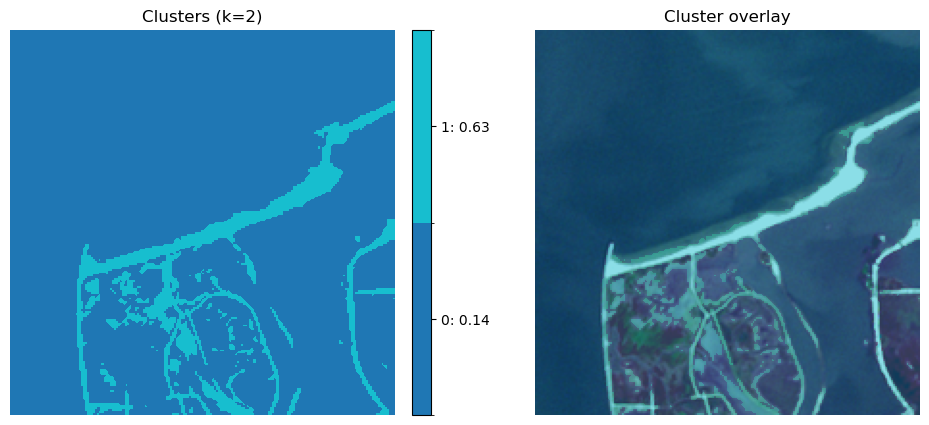

Patch 0: K-means done, water cluster: 0, cluster means: [0.14176703989505768, 0.634255051612854]


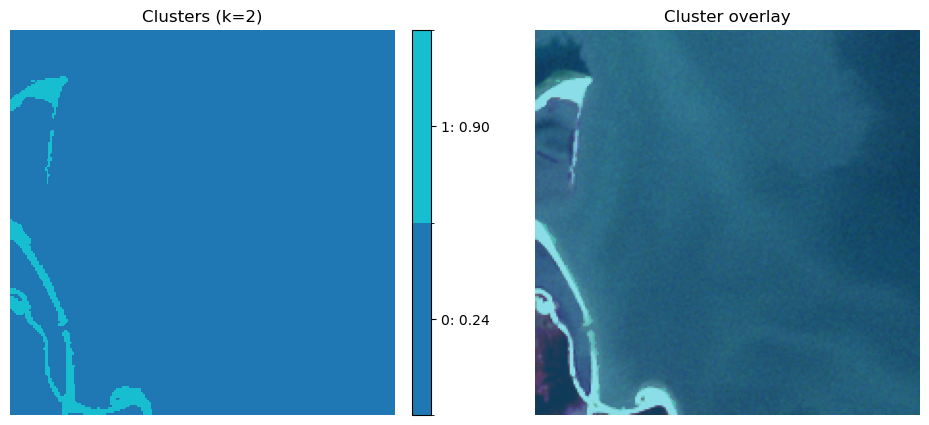

Patch 1: K-means done, water cluster: 0, cluster means: [0.24281711876392365, 0.9044085144996643]


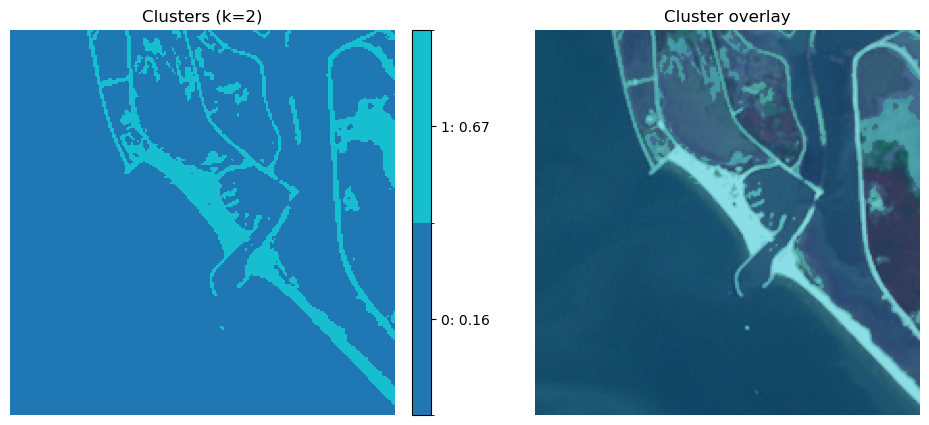

Patch 2: K-means done, water cluster: 0, cluster means: [0.1600843071937561, 0.6733309626579285]


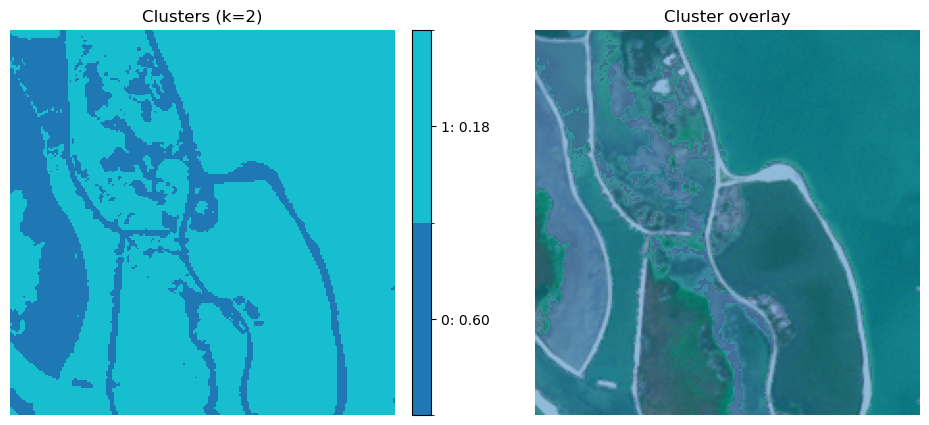

Patch 3: K-means done, water cluster: 1, cluster means: [0.5959723591804504, 0.17737933993339539]


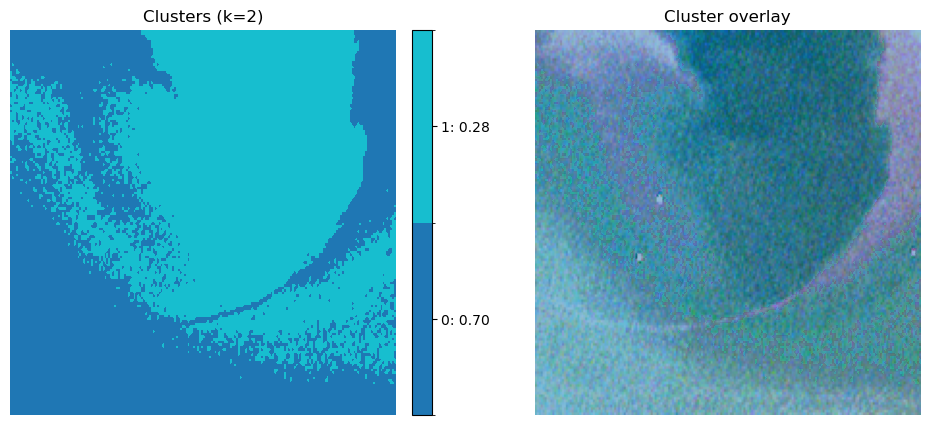

Patch 4: K-means done, water cluster: 1, cluster means: [0.6991586685180664, 0.27565836906433105]


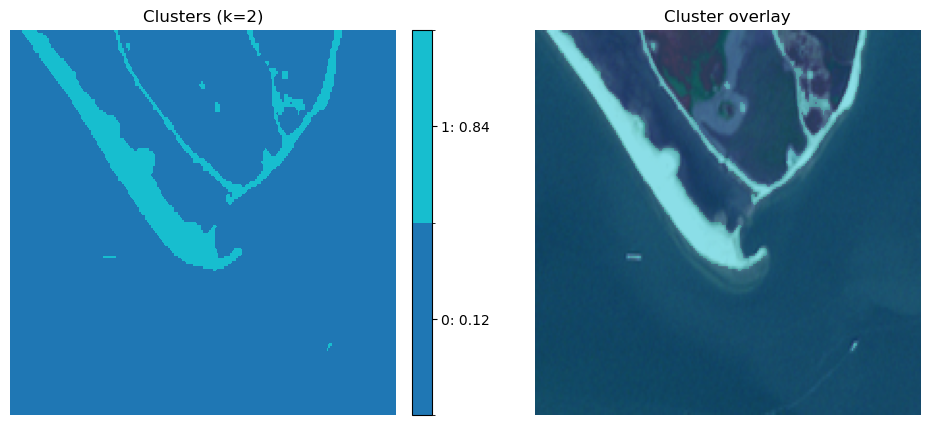

Patch 5: K-means done, water cluster: 0, cluster means: [0.11974408477544785, 0.841775119304657]


In [103]:
# implement K-means on each patch
for i, p in enumerate(patches):
    patch_img = p['patch']
    try:
        res = kmeans_shoreline(patch_img, k=2, transform=p['transform'], extent=p['bbox'], show_plot=True)
        p['kmeans_result'] = res
        print(f"Patch {i}: K-means done, water cluster: {res['water_cluster']}, cluster means: {res['cluster_means']}")
    except Exception as e:
        print(f"Patch {i}: K-means failed with error: {e}")